# Tabular CFR, built on the game tree



Run top to bottom in Colab. Pure Python — no installs, no data files, no GPU.

---

## The idea in one picture

A poker hand is a **tree**. The root is the deal, each branch is an action, and
each leaf is a showdown or a fold with a payoff attached.

```
                    (chance: deal cards)
                    /        |         \
              [J vs Q]    [Q vs K]   [K vs J]  ...
                 |
          P1 acts: check or bet
            /              \
      P2 acts            P2 acts
      /     \            /     \
   +1      ...        -1      +2      <- payoffs
```

If poker were chess, that tree would be the whole story: work backwards from the
leaves and you have optimal play. But poker has **hidden information**. When it's
your turn you don't know which of several tree nodes you're actually standing on,
because you can't see the opponent's card.

That is what an **information set** is: a bundle of tree nodes that look identical
to the player who has to act. You must play the *same* strategy at every node in
the bundle, because you cannot tell them apart.

**CFR is the algorithm that solves trees with information sets.** This notebook
builds the tree explicitly, shows you the information sets, and runs CFR over it.

## Why start with Kuhn poker

Because we can check the answer. Kuhn poker has a known exact solution, so every
claim below is verifiable rather than plausible:

| | Kuhn poker | Leduc hold'em |
|---|---|---|
| tree nodes | 55 | 9,451 |
| information sets | **12** | **288** |
| game value | exactly **−1/18** | ≈ **−0.0856** |

In [20]:
import random, time, math
from collections import defaultdict
from itertools import permutations

import matplotlib.pyplot as plt

random.seed(0)


---
# Part 1 · The game

**Kuhn poker** (Kuhn, 1950) is the smallest poker worth studying:

* three cards: J, Q, K. One dealt to each player, one unused.
* both players ante 1 chip
* player 1 acts: **pass** or **bet** (a bet costs 1 more chip)
* if a player passes facing a bet, they fold and lose their ante
* otherwise the higher card wins the pot

Five ways a hand can end: `pp`, `bp`, `bb`, `pbp`, `pbb`.

In [2]:
PASS, BET = 0, 1
ACTION_CHAR = {PASS: "p", BET: "b"}
CARD_NAME = {0: "J", 1: "Q", 2: "K"}
TERMINAL = {"pp", "bp", "bb", "pbp", "pbb"}
DEALS = list(permutations(range(3), 2))      # (card to P1, card to P2)

class KuhnState:
    """One node of the Kuhn poker tree."""
    def __init__(self, cards=None, history=""):
        self.cards = cards          # None at the root: cards not yet dealt
        self.history = history

    def is_chance(self):
        return self.cards is None

    def is_terminal(self):
        return self.cards is not None and self.history in TERMINAL

    def current_player(self):
        return len(self.history) % 2

    def legal_actions(self):
        return [PASS, BET]

    def chance_outcomes(self):
        return [(i, 1 / len(DEALS)) for i in range(len(DEALS))]

    def apply_action(self, a):
        if self.cards is None:
            return KuhnState(DEALS[a], "")
        return KuhnState(self.cards, self.history + ACTION_CHAR[a])

    def returns(self):
        """Payoff vector [to P1, to P2]."""
        h = self.history
        if h == "bp":  return [1.0, -1.0]        # P2 folded to a bet
        if h == "pbp": return [-1.0, 1.0]        # P1 folded to a bet
        v = 1.0 if h == "pp" else 2.0            # showdown: 1 chip, or 2 after bets
        return [v, -v] if self.cards[0] > self.cards[1] else [-v, v]

    def information_state_key(self):
        """Everything the acting player can see: their own card + the betting."""
        p = self.current_player()
        return f"{CARD_NAME[self.cards[p]]}{self.history}"

    def label(self):
        if self.cards is None: return "root (deal)"
        c = f"{CARD_NAME[self.cards[0]]}v{CARD_NAME[self.cards[1]]}"
        return f"{c}:{self.history or '-'}"

root = KuhnState()
s = root.apply_action(0)                          # deal J to P1, Q to P2
print("after the deal:", s.label())
print("  P1 sees:", s.information_state_key(), " (their card + betting so far)")
s2 = s.apply_action(BET)
print("after P1 bets:", s2.label())
print("  P2 sees:", s2.information_state_key())
print("  is terminal?", s2.is_terminal())

after the deal: JvQ:-
  P1 sees: J  (their card + betting so far)
after P1 bets: JvQ:b
  P2 sees: Qb
  is terminal? False


## Print the whole tree

Kuhn is small enough to look at in full. Below is the subtree for **one deal**
(J to player 1, Q to player 2). The full tree has six of these, one per deal.

Read `[P1] Jp` as: player 1 acts here, and the situation they can see is
"I hold the jack, one pass has happened".

In [3]:
def print_tree(state, depth=0, prefix="", max_deals=1):
    pad = "   " * depth
    if state.is_terminal():
        print(f"{pad}{prefix}-> payoff to P1: {state.returns()[0]:+.0f}")
        return
    if state.is_chance():
        print(f"{pad}chance: deals {len(DEALS)} equally likely hands")
        for i, (a, pr) in enumerate(state.chance_outcomes()[:max_deals]):
            child = state.apply_action(a)
            print(f"{pad}   deal {CARD_NAME[child.cards[0]]} to P1, "
                  f"{CARD_NAME[child.cards[1]]} to P2   (prob {pr:.3f})")
            print_tree(child, depth + 2)
        if len(DEALS) > max_deals:
            print(f"{pad}   ... {len(DEALS)-max_deals} more deals, same shape")
        return
    p = state.current_player()
    print(f"{pad}{prefix}[P{p+1}] sees \"{state.information_state_key()}\"")
    for a in state.legal_actions():
        name = "pass" if a == PASS else "bet"
        print_tree(state.apply_action(a), depth + 1, f"{name}: ")

print_tree(root)

chance: deals 6 equally likely hands
   deal J to P1, Q to P2   (prob 0.167)
      [P1] sees "J"
         pass: [P2] sees "Qp"
            pass: -> payoff to P1: -1
            bet: [P1] sees "Jpb"
               pass: -> payoff to P1: -1
               bet: -> payoff to P1: -2
         bet: [P2] sees "Qb"
            pass: -> payoff to P1: +1
            bet: -> payoff to P1: -2
   ... 5 more deals, same shape


## Information sets: where the difficulty lives

Now the crucial part. Walk the tree and group nodes by what the acting player can
*see*. Nodes that share a key are **indistinguishable** — the player must use one
strategy for all of them.

In [4]:
def walk(state):
    yield state
    if state.is_terminal(): return
    actions = ([a for a, _ in state.chance_outcomes()] if state.is_chance()
               else state.legal_actions())
    for a in actions:
        yield from walk(state.apply_action(a))

groups = defaultdict(list)
n_nodes = n_terminal = 0
for st in walk(root):
    n_nodes += 1
    if st.is_terminal(): n_terminal += 1
    elif not st.is_chance(): groups[st.information_state_key()].append(st.label())

print(f"tree nodes: {n_nodes}   terminals: {n_terminal}   information sets: {len(groups)}")
assert len(groups) == 12, "Kuhn should have exactly 12"
print("matches the published 12\n")

print("information set  -> tree nodes bundled inside it")
for key in sorted(groups):
    print(f"  {key:<5s} -> {', '.join(groups[key])}")

tree nodes: 55   terminals: 30   information sets: 12
matches the published 12

information set  -> tree nodes bundled inside it
  J     -> JvQ:-, JvK:-
  Jb    -> QvJ:b, KvJ:b
  Jp    -> QvJ:p, KvJ:p
  Jpb   -> JvQ:pb, JvK:pb
  K     -> KvJ:-, KvQ:-
  Kb    -> JvK:b, QvK:b
  Kp    -> JvK:p, QvK:p
  Kpb   -> KvJ:pb, KvQ:pb
  Q     -> QvJ:-, QvK:-
  Qb    -> JvQ:b, KvQ:b
  Qp    -> JvQ:p, KvQ:p
  Qpb   -> QvJ:pb, QvK:pb


Look at `Qb`: **"I hold the queen and my opponent has bet."** That single
information set covers two different tree nodes — the opponent might hold the jack
or the king. You cannot tell which, so you must play the *same* mix in both.

That is exactly why you can't just solve poker by backward induction, and exactly
what CFR is built to handle.

---
# Part 2 · Compile the tree into arrays

Walking Python objects works but allocates a new state per edge, which dominates
runtime on anything larger than Kuhn. So we flatten the tree **once** into parallel
arrays and let CFR run over integer indices.

Nodes are stored in DFS pre-order, which means **a parent always has a lower index
than its children**. We rely on that later.

In [5]:
TERM, CHANCE, PLAYER = 0, 1, 2

class GameTree:
    """The game tree, flattened into arrays."""
    def __init__(self, root_state):
        self.kind, self.player, self.infoset = [], [], []
        self.children, self.probs, self.util, self.actions = [], [], [], []
        self.keys, self.n_actions, self.iset_player, self.iset_nodes = [], [], [], []
        self.labels = []
        self._index = {}
        self._build(root_state)

    def _new(self):
        self.kind.append(TERM); self.player.append(-2); self.infoset.append(-1)
        self.children.append([]); self.probs.append([]); self.util.append([])
        self.actions.append([]); self.labels.append("")
        return len(self.kind) - 1

    def _iset(self, key, n, player):
        i = self._index.get(key)
        if i is None:
            i = len(self.keys); self._index[key] = i
            self.keys.append(key); self.n_actions.append(n)
            self.iset_player.append(player); self.iset_nodes.append([])
        elif self.n_actions[i] != n:
            raise ValueError(f"infoset {key!r} has inconsistent action counts")
        return i

    def _build(self, s):
        idx = self._new()
        self.labels[idx] = s.label()
        if s.is_terminal():
            self.kind[idx] = TERM; self.util[idx] = s.returns(); return idx
        if s.is_chance():
            out = s.chance_outcomes()
            self.kind[idx] = CHANCE
            self.probs[idx] = [p for _, p in out]
            self.children[idx] = [self._build(s.apply_action(a)) for a, _ in out]
            return idx
        legal, p = s.legal_actions(), s.current_player()
        i = self._iset(s.information_state_key(), len(legal), p)
        self.kind[idx] = PLAYER; self.player[idx] = p; self.infoset[idx] = i
        self.actions[idx] = legal; self.iset_nodes[i].append(idx)
        self.children[idx] = [self._build(s.apply_action(a)) for a in legal]
        return idx

    @property
    def num_nodes(self): return len(self.kind)
    @property
    def num_infosets(self): return len(self.keys)

    def summary(self):
        per = defaultdict(int)
        for p in self.iset_player: per[p] += 1
        return (f"{self.num_nodes} nodes, "
                f"{sum(1 for k in self.kind if k == TERM)} terminals, "
                f"{self.num_infosets} information sets "
                f"(P1: {per[0]}, P2: {per[1]})")

KUHN = GameTree(KuhnState())
print("Kuhn tree:", KUHN.summary())
print("\nfirst few nodes, in DFS pre-order:")
for i in range(6):
    kind = ["terminal", "chance", "player"][KUHN.kind[i]]
    print(f"  node {i:2d}  {kind:8s}  {KUHN.labels[i]:12s}  children: {KUHN.children[i]}")

Kuhn tree: 55 nodes, 30 terminals, 12 information sets (P1: 6, P2: 6)

first few nodes, in DFS pre-order:
  node  0  chance    root (deal)   children: [1, 10, 19, 28, 37, 46]
  node  1  player    JvQ:-         children: [2, 7]
  node  2  player    JvQ:p         children: [3, 4]
  node  3  terminal  JvQ:pp        children: []
  node  4  player    JvQ:pb        children: [5, 6]
  node  5  terminal  JvQ:pbp       children: []


---
# Part 3 · Regret matching

Here is the whole idea, and the one place people get it backwards.

After a hand, the **regret** for an action you did *not* take is how much better
off you would have been had you taken it:

$$r(a) = u(\text{play } a) - u(\text{what you actually did})$$

Then: **play each action in proportion to its positive regret.**

$$\sigma^{T+1}(I,a) = \frac{R^{T,+}(I,a)}{\sum_{a'} R^{T,+}(I,a')}$$

Note the direction carefully. "Regret" means regret for *not having taken* an
action, so a **large regret means you should do it more**, not less. Plenty of
write-ups state this backwards; further down we test the inverted rule and watch
it fail.

If no action has positive regret, play uniformly.

In [6]:
def regret_match(regrets):
    """Probabilities proportional to POSITIVE regret; uniform if none are."""
    pos = [r if r > 0 else 0.0 for r in regrets]
    total = sum(pos)
    if total > 0:
        return [x / total for x in pos]
    return [1.0 / len(regrets)] * len(regrets)

print("regrets [0, 1, 2]      ->", [round(x, 3) for x in regret_match([0, 1, 2])])
print("regrets [1, 3, 2]      ->", [round(x, 3) for x in regret_match([1, 3, 2])])
print("regrets [-1, -2, -3]   ->", [round(x, 3) for x in regret_match([-1, -2, -3])], "(all negative -> uniform)")

regrets [0, 1, 2]      -> [0.0, 0.333, 0.667]
regrets [1, 3, 2]      -> [0.167, 0.5, 0.333]
regrets [-1, -2, -3]   -> [0.333, 0.333, 0.333] (all negative -> uniform)


The first line is the rock-paper-scissors example from the Neller & Lanctot
tutorial: you played rock into paper, so you regret paper by 1 and scissors by 2,
and next time you play them in proportion 0 : 1/3 : 2/3.

## Counterfactual: the part that makes it work on a tree

One extra ingredient turns regret matching into CFR. A regret at some information
set only matters in proportion to **how likely you were to end up there at all** —
and specifically, how likely the *opponent and chance* were to let you.

So each regret is weighted by the **counterfactual reach probability**
$\pi^\sigma_{-i}(I)$: the probability of arriving at $I$ with the opponent's and
chance's contributions, but treating your *own* choices along the way as if you'd
deliberately played to get there.

This weighting is the only structural difference from plain regret matching, and
it is what makes the regrets across the whole tree add up correctly.

In [7]:
class CFR:
    """Tabular CFR over a compiled game tree."""

    def __init__(self, tree, plus=False):
        self.tree = tree
        self.plus = plus                     # CFR+ clamps negative regret at 0
        self.iterations = 0
        self.regret = [[0.0] * n for n in tree.n_actions]
        self.strategy_sum = [[0.0] * n for n in tree.n_actions]

    def strategy(self, iset):
        return regret_match(self.regret[iset])

    def train(self, iters):
        for _ in range(iters):
            self.iterations += 1
            w = float(self.iterations) if self.plus else 1.0
            for player in (0, 1):            # alternating updates
                self._cfr(0, player, 1.0, 1.0, w)

    def _cfr(self, node, player, reach_player, reach_cf, w):
        """Returns the expected value of `node` to `player`.

        reach_player : probability `player` played to get here
        reach_cf     : probability the OPPONENT and CHANCE allowed it
        """
        t = self.tree
        kind = t.kind[node]
        if kind == TERM:
            return t.util[node][player]

        kids = t.children[node]
        if kind == CHANCE:
            return sum(pr * self._cfr(c, player, reach_player, reach_cf * pr, w)
                       for c, pr in zip(kids, t.probs[node]))

        iset = t.infoset[node]
        sigma = self.strategy(iset)

        if t.player[node] == player:
            # value of each action, and of the mix
            util = [self._cfr(kids[i], player, reach_player * sigma[i], reach_cf, w)
                    for i in range(len(kids))]
            node_util = sum(sigma[i] * util[i] for i in range(len(kids)))

            r, ss = self.regret[iset], self.strategy_sum[iset]
            for i in range(len(kids)):
                # THE core update: regret, weighted by counterfactual reach
                new_r = r[i] + reach_cf * (util[i] - node_util)
                r[i] = max(new_r, 0.0) if self.plus else new_r
                # accumulate the average strategy, weighted by our own reach
                ss[i] += w * reach_player * sigma[i]
            return node_util

        # opponent's node: their action probabilities enter our counterfactual reach
        return sum(sigma[i] * self._cfr(kids[i], player, reach_player,
                                        reach_cf * sigma[i], w)
                   for i in range(len(kids)))

    def average_policy(self):
        """The average strategy over all iterations -- this converges to Nash."""
        out = {}
        for i in range(self.tree.num_infosets):
            ss = self.strategy_sum[i]; total = sum(ss)
            out[self.tree.keys[i]] = ([x / total for x in ss] if total > 0
                                      else [1 / len(ss)] * len(ss))
        return out

    def current_policy(self):
        return {self.tree.keys[i]: self.strategy(i)
                for i in range(self.tree.num_infosets)}

print("CFR ready")

CFR ready


## Watch the regrets build up

Let's train slowly and print the regret table for a few information sets, so you
can see the strategy forming out of accumulated regret rather than being told
about it.

In [8]:
solver = CFR(KUHN)
watch = ["K", "J", "Qb"]

print(f"{'iters':>6} | " + " | ".join(f"{k:^22s}" for k in watch))
print("-" * 78)
for target in (1, 5, 20, 100, 500, 2000):
    solver.train(target - solver.iterations)
    cells = []
    for k in watch:
        i = KUHN._index[k]
        r = self_r = self_r = solver.regret[i]
        sg = solver.strategy(i)
        cells.append(f"R={r[0]:+6.1f},{r[1]:+6.1f} p(bet)={sg[1]:.2f}")
    print(f"{solver.iterations:>6} | " + " | ".join(f"{c:^22s}" for c in cells))

print("\n(R = cumulative regret for [pass, bet]; p(bet) is what regret matching gives)")

 iters |           K            |           J            |           Qb          
------------------------------------------------------------------------------
     1 | R=  -0.1,  +0.1 p(bet)=1.00 | R=  -0.1,  +0.1 p(bet)=1.00 | R=  -0.1,  +0.2 p(bet)=1.00
     5 | R=  +0.0,  +0.1 p(bet)=0.98 | R=  +0.2,  -0.4 p(bet)=0.00 | R=  +0.3,  +0.1 p(bet)=0.16
    20 | R=  +0.2,  +0.3 p(bet)=0.60 | R=  +0.6,  -0.4 p(bet)=0.00 | R=  +0.6,  +0.2 p(bet)=0.20
   100 | R=  +0.4,  +0.6 p(bet)=0.59 | R=  +1.7,  +0.3 p(bet)=0.17 | R=  +0.9,  +0.9 p(bet)=0.52
   500 | R=  +0.6,  +1.3 p(bet)=0.69 | R=  +4.0,  +1.3 p(bet)=0.25 | R=  +2.6,  +0.9 p(bet)=0.26
  2000 | R=  +1.0,  +2.5 p(bet)=0.72 | R=  +8.1,  +2.1 p(bet)=0.21 | R=  +4.8,  +2.5 p(bet)=0.34

(R = cumulative regret for [pass, bet]; p(bet) is what regret matching gives)


Read the `K` column: the regret for betting climbs steadily, because betting the
king keeps turning out better than passing. Regret matching converts that into a
high probability of betting. Nobody told it the king is strong — it learned that
from payoffs alone.

`J` is more interesting: it settles into a *mix*. Bluffing the jack sometimes is
mandatory, because a player who only bets good hands is trivially exploitable.

---
# Part 4 · Was it right? Measuring exploitability

"It looks like it's learning" is not evidence. The real test: if an opponent knew
our strategy exactly and played the perfect counter, how much would they win?

That's **exploitability**. Zero means unbeatable — a genuine Nash equilibrium.

Computing it exactly needs one subtlety. The best-responding opponent also faces
information sets, so they must pick **one action for the whole information set**.
We resolve each information set once by aggregating over every tree node inside
it, weighted by how likely we and chance were to allow that node.

In [9]:
def policy_at(tree, policy, iset):
    p = policy.get(tree.keys[iset])
    return p if p else [1 / tree.n_actions[iset]] * tree.n_actions[iset]

def expected_value(tree, policy):
    """Expected payoff per hand when both sides follow `policy`."""
    memo = {}
    def rec(node):
        if node in memo: return memo[node]
        kind = tree.kind[node]
        if kind == TERM: out = list(tree.util[node])
        elif kind == CHANCE:
            out = [0.0, 0.0]
            for c, pr in zip(tree.children[node], tree.probs[node]):
                s = rec(c); out[0] += pr * s[0]; out[1] += pr * s[1]
        else:
            sg = policy_at(tree, policy, tree.infoset[node]); out = [0.0, 0.0]
            for i, c in enumerate(tree.children[node]):
                if sg[i] <= 0: continue
                s = rec(c); out[0] += sg[i] * s[0]; out[1] += sg[i] * s[1]
        memo[node] = out; return out
    return rec(0)

def best_response_value(tree, policy, player):
    n = tree.num_nodes
    reach = [0.0] * n; reach[0] = 1.0
    # one forward pass: parents precede children in pre-order, so this works
    for node in range(n):
        r = reach[node]
        if r == 0.0 or tree.kind[node] == TERM: continue
        kids = tree.children[node]
        if tree.kind[node] == CHANCE:
            for c, pr in zip(kids, tree.probs[node]): reach[c] += r * pr
        elif tree.player[node] == player:
            for c in kids: reach[c] += r            # responder's own choice: weight 1
        else:
            sg = policy_at(tree, policy, tree.infoset[node])
            for i, c in enumerate(kids):
                if sg[i] > 0: reach[c] += r * sg[i]

    choice, memo = {}, [None] * n
    def value(node):
        if memo[node] is not None: return memo[node]
        kind = tree.kind[node]
        if kind == TERM: v = tree.util[node][player]
        elif kind == CHANCE:
            v = sum(pr * value(c) for c, pr in zip(tree.children[node], tree.probs[node]))
        else:
            iset = tree.infoset[node]
            if tree.player[node] == player:
                if iset not in choice:              # resolve the WHOLE infoset at once
                    acc = [0.0] * tree.n_actions[iset]
                    for m in tree.iset_nodes[iset]:
                        if reach[m] == 0.0: continue
                        for i, c in enumerate(tree.children[m]):
                            acc[i] += reach[m] * value(c)
                    choice[iset] = max(range(len(acc)), key=lambda i: acc[i])
                v = value(tree.children[node][choice[iset]])
            else:
                sg = policy_at(tree, policy, iset)
                v = sum(sg[i] * value(c)
                        for i, c in enumerate(tree.children[node]) if sg[i] > 0)
        memo[node] = v; return v
    return value(0)

def exploitability(tree, policy):
    return (best_response_value(tree, policy, 0)
            + best_response_value(tree, policy, 1)) / 2

### First: test the measuring instrument, not the solver

If the exploitability code is wrong, everything below is meaningless *and will
still look plausible*. So check it against something known independently.

Kuhn's optimal strategies form a known one-parameter family: player 1 bluffs the
jack with probability $\alpha \in [0, 1/3]$ and bets the king at exactly $3\alpha$.
Feed that closed form in. A true equilibrium must measure as **exactly
unexploitable**.

In [10]:
def kuhn_equilibrium(alpha):
    return {
        "J":   [1 - alpha, alpha],        "Q":   [1.0, 0.0],
        "K":   [1 - 3 * alpha, 3 * alpha],
        "Jp":  [2/3, 1/3],                "Qp":  [1.0, 0.0],   "Kp":  [0.0, 1.0],
        "Jb":  [1.0, 0.0],                "Qb":  [2/3, 1/3],   "Kb":  [0.0, 1.0],
        "Jpb": [1.0, 0.0],                "Qpb": [2/3 - alpha, alpha + 1/3],
        "Kpb": [0.0, 1.0],
    }

for alpha in (0.0, 1/6, 1/3):
    pol = kuhn_equilibrium(alpha)
    print(f"alpha={alpha:.3f}  value={expected_value(KUHN, pol)[0]:+.9f}  "
          f"exploitability={exploitability(KUHN, pol):.2e}")
print(f"\ntarget game value: -1/18 = {-1/18:+.9f}")

alpha=0.000  value=-0.055555556  exploitability=0.00e+00
alpha=0.167  value=-0.055555556  exploitability=2.08e-17
alpha=0.333  value=-0.055555556  exploitability=6.94e-18

target game value: -1/18 = -0.055555556


Exploitability at **machine precision** (1e-17), and the value pinned to −1/18 for
every member of the family. The evaluator is trustworthy. *Now* we can use it to
judge CFR.

In [11]:
solver = CFR(KUHN)
rows = []
for target in (1, 10, 100, 1000, 10000):
    solver.train(target - solver.iterations)
    pol = solver.average_policy()
    e, v = exploitability(KUHN, pol), expected_value(KUHN, pol)[0]
    rows.append((target, e))
    print(f"T={target:6d}  exploitability={e:.5f}  value={v:+.6f}")
print(f"\ntrue value: {-1/18:+.6f}")

T=     1  exploitability=0.27083  value=+0.000000
T=    10  exploitability=0.06538  value=-0.058196
T=   100  exploitability=0.02336  value=-0.057093
T=  1000  exploitability=0.00650  value=-0.055707
T= 10000  exploitability=0.00214  value=-0.055571

true value: -0.055556


In [12]:
final = solver.average_policy()
alpha = final["J"][1]
print("What CFR discovered, versus 1950 theory:\n")
print(f"  bluffs the jack with alpha = {alpha:.3f}")
print(f"  theory says bet the king at 3*alpha = {3*alpha:.3f};  CFR plays {final['K'][1]:.3f}")
print()
for key, theory in [("Q", "never bet"), ("Qb", "fold 2/3 of the time"),
                    ("Kb", "always call"), ("Jb", "always fold")]:
    print(f"  {key:<4s} pass/bet = {final[key][0]:.3f} / {final[key][1]:.3f}"
          f"   (theory: {theory})")

What CFR discovered, versus 1950 theory:

  bluffs the jack with alpha = 0.235
  theory says bet the king at 3*alpha = 0.705;  CFR plays 0.691

  Q    pass/bet = 0.999 / 0.001   (theory: never bet)
  Qb   pass/bet = 0.660 / 0.340   (theory: fold 2/3 of the time)
  Kb   pass/bet = 0.000 / 1.000   (theory: always call)
  Jb   pass/bet = 1.000 / 0.000   (theory: always fold)


The bot rediscovered Kuhn's solution from self-play alone. It was never shown a
strategy — only its own regrets.

---
# Part 5 · Two things every CFR write-up gets wrong

## 5.1 · The regret direction

Many introductions state the update as *"assign higher probability to actions with
**lower** regret."* That is backwards. Let's implement the inverted rule and
measure it.

In [13]:
class InvertedCFR(CFR):
    """The rule as it is often mis-stated: favour LOW-regret actions."""
    def strategy(self, iset):
        r = self.regret[iset]
        top = max(r)
        w = [top - x for x in r]              # higher weight to lower regret
        s = sum(w)
        return [x / s for x in w] if s > 0 else [1 / len(r)] * len(r)

correct = CFR(KUHN); correct.train(5000)
wrong = InvertedCFR(KUHN); wrong.train(5000)

print(f"correct  (prob ∝ POSITIVE regret): exploitability {exploitability(KUHN, correct.average_policy()):.4f}"
      f"   value {expected_value(KUHN, correct.average_policy())[0]:+.4f}")
print(f"inverted (prob ∝ LOW regret)     : exploitability {exploitability(KUHN, wrong.average_policy()):.4f}"
      f"   value {expected_value(KUHN, wrong.average_policy())[0]:+.4f}")
print(f"\ntrue value {-1/18:+.4f}")

correct  (prob ∝ POSITIVE regret): exploitability 0.0030   value -0.0556
inverted (prob ∝ LOW regret)     : exploitability 0.9166   value -0.0000

true value -0.0556


The inverted rule is **hundreds of times more exploitable** and converges to the
wrong game value. It doesn't approximate equilibrium at all — it systematically
avoids good actions.

Worth keeping as a slide: it shows the algorithm is doing real work, and isn't
just "play more, get better."

## 5.2 · Average or current strategy?

Every tutorial says: extract the **average** strategy, not the final one. That is
correct for plain CFR — the individual iterates oscillate wildly and never settle.

But it **reverses for CFR+**, a common variant that clamps cumulative regret at
zero. The clamping damps the oscillation so hard that the current strategy
converges, while the average is still weighed down by poor early iterations it can
never forget.

In [14]:
print(f"{'variant':<10s} {'T':>6s} {'average':>12s} {'current':>12s}")
print("-" * 44)
for name, plus in [("CFR", False), ("CFR+", True)]:
    s = CFR(KUHN, plus=plus)
    for T in (100, 1000, 10000):
        s.train(T - s.iterations)
        print(f"{name:<10s} {T:>6d} {exploitability(KUHN, s.average_policy()):>12.5f} "
              f"{exploitability(KUHN, s.current_policy()):>12.5f}")
print("\nrule of thumb:  plain CFR -> read the AVERAGE.  CFR+ -> read the CURRENT.")

variant         T      average      current
--------------------------------------------
CFR           100      0.02336      0.03012
CFR          1000      0.00650      0.01522
CFR         10000      0.00214      0.00251
CFR+          100      0.01479      0.01133
CFR+         1000      0.00485      0.00279
CFR+        10000      0.00152      0.00059

rule of thumb:  plain CFR -> read the AVERAGE.  CFR+ -> read the CURRENT.


---
# Part 6 · The same code on a bigger tree

Nothing above was Kuhn-specific: `GameTree`, `CFR` and `exploitability` only ever
call `is_terminal`, `legal_actions`, `apply_action`, `returns` and
`information_state_key`. So a new game just needs a new state class.

**Leduc hold'em** is the standard next step up: a 6-card deck (J, Q, K in two
suits), two betting rounds with a **public card** dealt in between, bets of 2 then
4, and at most two raises per round. Pairing the public card wins.

That's 9,451 tree nodes and **288 information sets** — 24× Kuhn.

In [15]:
LR = "JQK"
LBET = (2, 4)
LMAX_RAISES = 2
FOLD, CALL, RAISE = 0, 1, 2
lrank = lambda c: c // 2

class LeducState:
    def __init__(self, hole=None, public=None, rnd=0, seq="", hist="",
                 committed=None, street=None, folder=None):
        self.hole = hole; self.public = public; self.rnd = rnd
        self.seq = seq; self.hist = hist
        self.committed = committed if committed is not None else [1, 1]
        self.street = street if street is not None else [0, 0]
        self.folder = folder

    def round_closed(self):
        s = self.seq
        if not s: return False
        if s[-1] == "f" or s == "cc": return True
        return len(s) >= 2 and s[-1] == "c" and s[-2] == "r"

    def is_terminal(self):
        return self.folder is not None or (self.rnd == 1 and self.round_closed())
    def is_chance(self):
        return self.hole is None or (self.rnd == 1 and self.public is None)
    def current_player(self): return len(self.seq) % 2
    def facing_bet(self): return bool(self.seq) and self.seq[-1] == "r"

    def legal_actions(self):
        a = []
        if self.facing_bet(): a.append(FOLD)
        a.append(CALL)
        if self.seq.count("r") < LMAX_RAISES: a.append(RAISE)
        return a

    def chance_outcomes(self):
        if self.hole is None:
            d = [(x, y) for x in range(6) for y in range(6) if x != y]
            return [(i, 1 / len(d)) for i in range(len(d))]
        rest = [c for c in range(6) if c not in self.hole]
        return [(c, 1 / len(rest)) for c in rest]

    def apply_action(self, a):
        if self.hole is None:
            d = [(x, y) for x in range(6) for y in range(6) if x != y]
            return LeducState(hole=d[a])
        if self.rnd == 1 and self.public is None:
            return LeducState(self.hole, a, 1, "", self.hist + "/",
                              list(self.committed), [0, 0])
        p = len(self.seq) % 2
        street, committed, folder = list(self.street), list(self.committed), None
        if a == FOLD: folder = p
        elif a == CALL: street[p] = max(street)
        else: street[p] = max(street) + LBET[self.rnd]
        n = LeducState(self.hole, self.public, self.rnd, self.seq + "fcr"[a],
                       self.hist + "fcr"[a], committed, street, folder)
        if n.round_closed():
            n.committed = [committed[i] + street[i] for i in range(2)]
            n.street = [0, 0]
            if folder is None and n.rnd == 0:
                n.rnd, n.seq, n.public = 1, "", None
        return n

    def returns(self):
        if self.folder is not None:
            amt = float(self.committed[self.folder])
            return [-amt, amt] if self.folder == 0 else [amt, -amt]
        pub = lrank(self.public); r0, r1 = lrank(self.hole[0]), lrank(self.hole[1])
        p0, p1 = (r0 == pub), (r1 == pub)
        amt = float(self.committed[0])
        if p0 != p1: return [amt, -amt] if p0 else [-amt, amt]
        if r0 == r1: return [0.0, 0.0]
        return [amt, -amt] if r0 > r1 else [-amt, amt]

    def information_state_key(self):
        p = self.current_player()
        pub = LR[lrank(self.public)] if self.public is not None else "?"
        return f"{LR[lrank(self.hole[p])]}{pub}|{self.hist}"

    def label(self):
        return f"{self.hist or '-'}"

t0 = time.time()
LEDUC = GameTree(LeducState())
print("Leduc tree:", LEDUC.summary(), f"  (built in {time.time()-t0:.1f}s)")
assert LEDUC.num_infosets == 288
print("matches the published 288")

Leduc tree: 9451 nodes, 5520 terminals, 288 information sets (P1: 144, P2: 144)   (built in 0.0s)
matches the published 288


In [16]:
t0 = time.time()
lsolver = CFR(LEDUC, plus=True)
leduc_curve = []
for T in (10, 50, 200, 600, 1500):
    lsolver.train(T - lsolver.iterations)
    pol = lsolver.current_policy()          # CFR+ -> read the current strategy
    e, v = exploitability(LEDUC, pol), expected_value(LEDUC, pol)[0]
    leduc_curve.append((T, e))
    print(f"T={T:5d}  exploitability={e:.5f}  value={v:+.6f}   ({time.time()-t0:.0f}s)")
print("\npublished game value: -0.0856")

T=   10  exploitability=0.66291  value=-0.507478   (0s)
T=   50  exploitability=0.08736  value=-0.081337   (2s)
T=  200  exploitability=0.02186  value=-0.084714   (7s)
T=  600  exploitability=0.00900  value=-0.084552   (21s)
T= 1500  exploitability=0.00555  value=-0.084913   (50s)

published game value: -0.0856


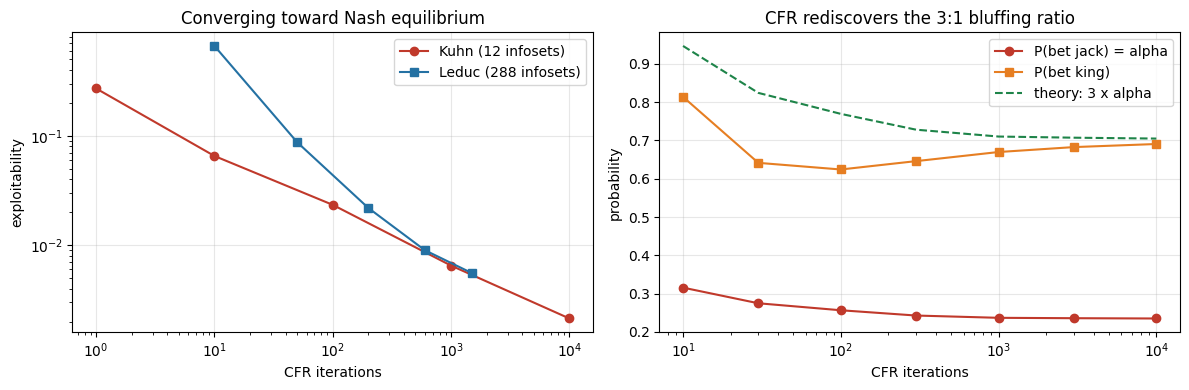

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot([r[0] for r in rows], [r[1] for r in rows], "o-",
           color="#C0392B", label="Kuhn (12 infosets)")
ax[0].plot([r[0] for r in leduc_curve], [r[1] for r in leduc_curve], "s-",
           color="#2471A3", label="Leduc (288 infosets)")
ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_xlabel("CFR iterations"); ax[0].set_ylabel("exploitability")
ax[0].set_title("Converging toward Nash equilibrium")
ax[0].legend(); ax[0].grid(alpha=.3)

s = CFR(KUHN); alphas = []; xs = []
for T in (10, 30, 100, 300, 1000, 3000, 10000):
    s.train(T - s.iterations)
    p = s.average_policy(); xs.append(T); alphas.append((p["J"][1], p["K"][1]))
ax[1].plot(xs, [a[0] for a in alphas], "o-", color="#C0392B", label="P(bet jack) = alpha")
ax[1].plot(xs, [a[1] for a in alphas], "s-", color="#E67E22", label="P(bet king)")
ax[1].plot(xs, [3 * a[0] for a in alphas], "--", color="#1E8449", label="theory: 3 x alpha")
ax[1].set_xscale("log"); ax[1].set_xlabel("CFR iterations")
ax[1].set_ylabel("probability"); ax[1].set_title("CFR rediscovers the 3:1 bluffing ratio")
ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

---
# Part 7 · Play the bot

In [18]:
def bot_action(state, policy, rng=random):
    key = state.information_state_key()
    legal = state.legal_actions()
    probs = policy.get(key, [1 / len(legal)] * len(legal))
    if len(probs) != len(legal): probs = [1 / len(legal)] * len(legal)
    r, acc = rng.random() * sum(probs), 0.0
    for i, p in enumerate(probs):
        acc += p
        if r < acc: return legal[i], probs
    return legal[-1], probs

def play_kuhn(policy, hands=5, rng=random, human_fn=None):
    total = 0
    names = {PASS: "pass", BET: "bet"}
    for h in range(hands):
        s = KuhnState().apply_action(rng.randrange(len(DEALS)))
        print(f"--- hand {h+1} --- your card: {CARD_NAME[s.cards[0]]}")
        while not s.is_terminal():
            if s.current_player() == 0:
                legal = s.legal_actions()
                a = human_fn(s, legal) if human_fn else (BET if s.cards[0] == 2 else PASS)
                print(f"  you: {names[a]}")
            else:
                a, probs = bot_action(s, policy, rng)
                mix = ", ".join(f"{names[i]} {probs[i]*100:.0f}%" for i in range(2))
                print(f"  bot: {names[a]}   (its mix: {mix})")
            s = s.apply_action(a)
        r = s.returns()[0]; total += r
        print(f"  bot had {CARD_NAME[s.cards[1]]} -> you {r:+.0f}\n")
    print(f"total {total:+.0f} chips over {hands} hands")

random.seed(3)
play_kuhn(final, hands=4)

--- hand 1 --- your card: J
  you: pass
  bot: bet   (its mix: pass 0%, bet 100%)
  you: pass
  bot had K -> you -1

--- hand 2 --- your card: J
  you: pass
  bot: bet   (its mix: pass 0%, bet 100%)
  you: pass
  bot had K -> you -1

--- hand 3 --- your card: K
  you: bet
  bot: pass   (its mix: pass 100%, bet 0%)
  bot had J -> you +1

--- hand 4 --- your card: K
  you: bet
  bot: pass   (its mix: pass 100%, bet 0%)
  bot had J -> you +1

total +0 chips over 4 hands


### Play it yourself

Run this and type the number of the action you want.

In [19]:
def ask(state, legal):
    names = {PASS: "pass/check/fold", BET: "bet/call"}
    opts = " | ".join(f"[{i}] {names[a]}" for i, a in enumerate(legal))
    while True:
        raw = input(f"  {opts}: ").strip()
        if raw.isdigit() and int(raw) < len(legal): return legal[int(raw)]
        print("   pick one of the listed numbers")

play_kuhn(final, hands=5, human_fn=ask)

--- hand 1 --- your card: J
  [0] pass/check/fold | [1] bet/call: 0
  you: pass
  bot: pass   (its mix: pass 100%, bet 0%)
  bot had Q -> you -1

--- hand 2 --- your card: Q
  [0] pass/check/fold | [1] bet/call: 1
  you: bet
  bot: bet   (its mix: pass 0%, bet 100%)
  bot had K -> you -2

--- hand 3 --- your card: J
  [0] pass/check/fold | [1] bet/call: 0
  you: pass
  bot: bet   (its mix: pass 0%, bet 100%)
  [0] pass/check/fold | [1] bet/call: 0
  you: pass
  bot had K -> you -1

--- hand 4 --- your card: K
  [0] pass/check/fold | [1] bet/call: 1
  you: bet
  bot: pass   (its mix: pass 66%, bet 34%)
  bot had Q -> you +1

--- hand 5 --- your card: K
  [0] pass/check/fold | [1] bet/call: 1
  you: bet
  bot: pass   (its mix: pass 100%, bet 0%)
  bot had J -> you +1

total -2 chips over 5 hands


---
# What to say about this project

**One line.** We represented poker as a game tree with information sets,
implemented tabular CFR over it, and verified the resulting bot is
game-theory-optimal against known exact solutions.

**Results.**

| | Kuhn poker | Leduc hold'em |
|---|---|---|
| information sets | 12 ✓ | 288 ✓ |
| game value found | −0.0556 (exact: −1/18) | −0.0851 (published −0.0856) |
| exploitability | ~1e-3 | ~4e-3 |

CFR also rediscovered Kuhn's 1950 solution unaided: bluff the jack with
probability α, bet the king at exactly 3α, fold the queen two-thirds of the time
facing a bet.

**Three things we verified rather than assumed.**

1. We validated the *measuring instrument* before the solver — feeding the
   closed-form optimal strategy into the exploitability code returned ~1e-17. If
   that code were wrong, every other number would look fine and mean nothing.
2. The regret direction is *proportional to positive regret*. Implementing the
   commonly mis-stated inverted rule made the bot hundreds of times more
   exploitable and converged to the wrong game value.
3. Read the **average** strategy for plain CFR, but the **current** strategy for
   CFR+ — the standard advice reverses, and we measured both.

**Honest limitations.**

* Tabular CFR needs one table entry per information set, so it cannot reach real
  poker (~10¹⁷). Scaling needs abstraction or a neural approximation (Deep CFR).
* We solve two-player zero-sum games. Nash equilibrium loses its guarantees with
  three or more players.
* An equilibrium strategy is **unexploitable, not maximally profitable**. It
  doesn't punish weak opponents — it just refuses to lose.

### References

* Zinkevich, Johanson, Bowling & Piccione, *Regret Minimization in Games with Incomplete Information*, NIPS 2007
* Neller & Lanctot, *An Introduction to Counterfactual Regret Minimization*, 2013
* Kuhn, *Simplified Two-Person Poker*, 1950